# $NO_3$ experiment

## Methods
The concentration of NO3 used was 10 uM


In [1]:
import pandas as pd
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt

import pickle as pk
import re
import glob 

import pkl_dac_gather as op

from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from matplotlib.collections import LineCollection

In [2]:

# MAIN_DIR = 'C:/Users/Rustam/Desktop/test/20250612_1/' #pkl files folder
# FNS = np.sort(glob.glob(MAIN_DIR + '*pkl'))

# folder_path = "C:/Users/Rustam/Desktop/test/20250612_1/" #wv file folder
# abs_list = []
# metadata = []
# wvr = pd.read_csv("C:/Users/Rustam/Downloads/WV.csv").iloc[0, 1]
# wv_cleaned = re.sub(r'[\[\]\n]', ' ', wvr)
# wv = np.fromstring(wv_cleaned, sep=' ')

# file_path = "C:/Users/Rustam/Desktop/test/20250612/20250612/CALIBRAT.DAT"  #dat file path

In [3]:
MAIN_DIR = '../74B9/'

DIN = MAIN_DIR + '20250619_no3/'
FNS = np.sort(glob.glob(DIN + 'opus*pkl'))

FN_CAL = DIN + 'DAT/CALIBRAT.DAT'

In [4]:
# read wavelengths
wvr = pd.read_csv(MAIN_DIR + 'wv_74B9.csv').iloc[0, 1]
wv_cleaned = re.sub(r'[\[\]\n]', ' ', wvr)
wv = np.fromstring(wv_cleaned, sep=' ')

In [5]:
ds = op.mk_xr_dataset(FNS, wv)
ds, Ts_opus = op.add_all_temps(FN_CAL, ds) # add all temperatures
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 880, wv: 248)
Coordinates:
  * time         (time) datetime64[ns] 7kB 2025-06-19T12:58:06.027884032 ... ...
  * wv           (wv) float64 2kB 191.0 191.8 192.5 193.3 ... 385.4 386.2 387.0
Data variables:
    Intensity    (time, wv) float64 2MB 1.146e+04 1.173e+04 ... -1.764 0.05757
    lampR0       (time) float64 7kB 1.675e+04 1.648e+04 ... 1.689e+04 1.69e+04
    lampR1       (time) float64 7kB 3.837e+03 3.751e+03 ... 3.88e+03 3.882e+03
    T            (time) float64 7kB 24.16 24.34 24.44 24.5 ... 29.88 29.88 29.88
    Fcount       (time) float64 7kB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    T_RefDiode   (time) float64 7kB 24.38 24.85 25.08 ... 29.69 29.69 29.69
    T_RefSpectr  (time) float64 7kB 24.15 24.34 24.42 24.5 ... 29.87 29.87 29.87
    T_CPU        (time) float64 7kB 24.2 24.7 24.89 25.0 ... 31.9 31.9 31.9 31.9

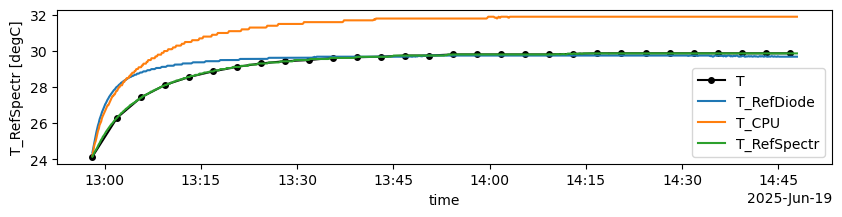

In [6]:
fig, ax = plt.subplots(1, figsize=[10,2], sharex=True)
ds['T'][::30].plot(marker='o', ms=4, c='k', ax=ax, label='T')
ds['T_RefDiode'].plot(ax=ax, label='T_RefDiode')
ds['T_CPU'].plot(ax=ax, label='T_CPU')
ds['T_RefSpectr'].plot(ax=ax, label='T_RefSpectr')

ax.legend()

In [7]:
io = 0
ilast = 2000

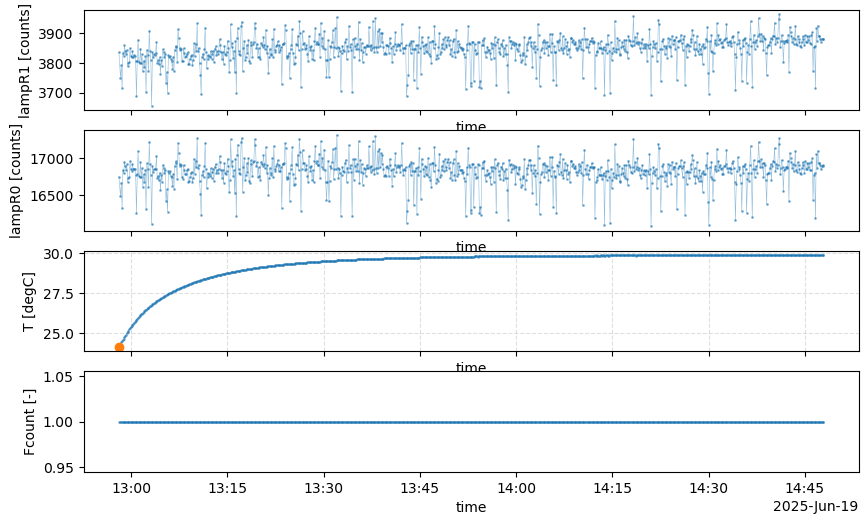

In [8]:
fig, ax = plt.subplots(4,1, figsize=[10,6], sharex=True)

ds['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0], label=None)
ds['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1])
ds['T'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[2])
ds['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3])

ax[2].grid(ls='--', alpha=0.4)

ax[2].plot(ds['time'][io], ds['T'][io], 'o')
# ax[3].set_xlim([pd.to_datetime('2025-06-12 16:40'), pd.to_datetime('2025-06-12 16:45')])

In [9]:
# i2use = np.where(ds['time'] >= pd.to_datetime('2025-06-12 16:41'))
# i2use = np.where(  (ds['time'] >= pd.to_datetime('2025-06-12 16:41')) &  (ds['time'] <= pd.to_datetime('2025-06-12 18:41'))  )
# i2use = np.arange(0, lR1.size, 1)
# i2use = np.arange(1250, 2000, 1)
# i2use = np.where(Fcount == 1)[0]
io    = np.where(ds['time'].values >= pd.to_datetime('2025-06-19 15:00'))[0]
ilast = np.where(ds['time'].values <= pd.to_datetime('2025-06-19 16:00'))[0]

ds2 = ds.sel(   time=slice('2025-06-19 12:30',   '2025-06-19 14:45' )  ) # this is to ensure that the temperature distribution is uniform

# ds2 = ds.sel(time=slice(pd.to_datetime('2025-06-12 16:41'), pd.to_datetime('2025-06-12 23:59')))
# ds2 = ds.sel(time=slice(pd.to_datetime('2025-06-12 16:41'), pd.to_datetime('2025-06-12 22:41')))

io

array([], dtype=int64)

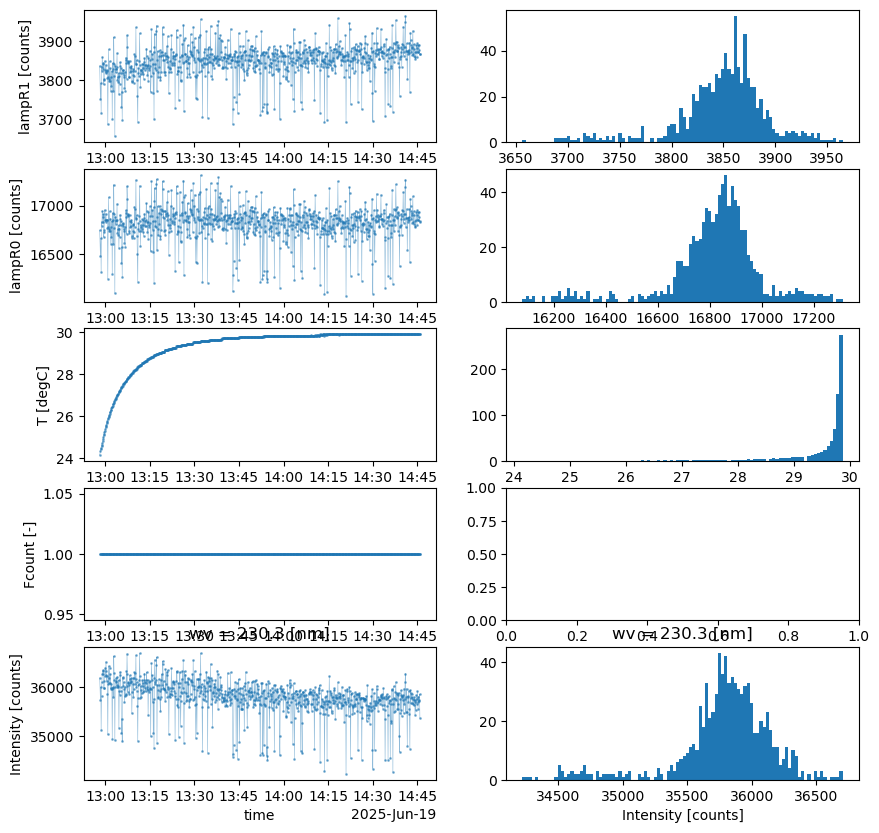

In [10]:
iwv = 50


fig, ax = plt.subplots(5,2, figsize=[10,10], sharex=False)

ds2['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0,0], label=None)
ax[0,0].set_xlabel('')
ds2['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1,0])
ax[1,0].set_xlabel('')
ds2['T'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[2,0])
ax[2,0].set_xlabel('')
ds2['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3,0])
ax[3,0].set_xlabel('')

ds2['Intensity'][:,iwv].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[4,0])



ds2['lampR1'].plot.hist(bins=100, ax=ax[0,1]); 
ds2['lampR0'].plot.hist(bins=100, ax=ax[1,1]);
ds2['T'].plot.hist(bins=100, ax=ax[2,1]);
ds2['Intensity'][:,iwv].plot.hist(bins=100, ax=ax[4,1]);


## Now create $NO_3$ intensity spectrum at the standard $R_0$ and $T_0$ values

We define $R_0 = 3825$ counts (i.e., approximately the centre of the distribution of R values measured in this experiment) and $T_0 = 20 ^\circ$C (a temperature in the middle of the range meaured).

We then convert all intensity spectra measured to these standard values and compute the median and robust standard deviation of the resulting spectra to create a standard pure-water spectrum.

In [11]:
ds_fit = xr.open_dataset(MAIN_DIR + 'Basis_spectra/lampRef1_T_fit.nc')
ds_fit

<xarray.Dataset> Size: 6kB
Dimensions:  (wv: 248)
Coordinates:
  * wv       (wv) float64 2kB 191.0 191.8 192.5 193.3 ... 385.4 386.2 387.0
Data variables:
    m_lRef1  (wv) float64 2kB ...
    m_T      (wv) float64 2kB ...

In [12]:
# define standard values
R0 = 3825 # [counts]
T0 = 20 # [degC]

In [13]:
T_col = 'T'
# create and apply correction
I = ds2['Intensity'].values

# NOTE: we put the values we want to correct towards (i.e., R_0 and T_0) as first terms in the differences below
dR = R0 - ds2['lampR1'].values
dT = T0 - ds2[T_col].values

I_corr  = I    +   ds_fit['m_lRef1'].values * dR.reshape(-1,1)   +   ds_fit['m_T'].values * dT.reshape(-1,1)


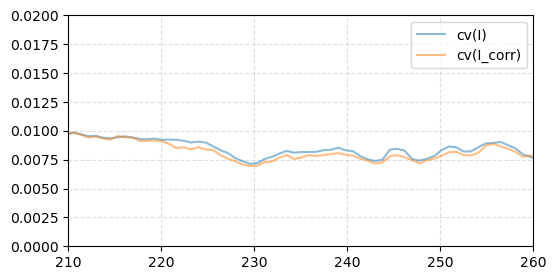

In [14]:
def prcrng(x):

    return (np.nanpercentile(x, 84, axis=0) - np.nanpercentile(x, 16, axis=0))/2



fig, ax = plt.subplots(1, figsize=[6,3])

ax.plot(ds2['wv'], prcrng(I) / np.median(I, axis=0), alpha=0.5, label='cv(I)')
ax.plot(ds2['wv'], prcrng(I_corr) / np.median(I_corr, axis=0), alpha=0.5, label='cv(I_corr)')
# ax.plot(ds2['wv'], prcrng(I) , alpha=0.5, label='rstd(I)')
# ax.plot(ds2['wv'], prcrng(I_corr), alpha=0.5, label='rstd(I_corr)')

# ax.set_ylim([0, 500])
ax.set_ylim([0, 0.02])
ax.set_xlim([210, 260])

ax.grid(ls='--', alpha=0.4)

ax.legend()

In [15]:
ds_Ipw = xr.open_dataset(MAIN_DIR + 'Basis_spectra/Ipw.nc')
ds_Ipw.close()

In [19]:
fnno3 = '/Users/gdal/Dropbox/Project/Itineris/OPUS/Cals/74B9/20250519_085118_N-NO3_SubstanceBasis_74B9.dat'
A_NO3_trios = pd.read_csv(fnno3, skiprows=39, sep=' ', usecols=[0,1], nrows=248, names=['wv', 'A_NO3_TriOS'], index_col=0)

In [20]:
A_NO3_trios['A_NO3_TriOS'] = A_NO3_trios['A_NO3_TriOS'] / 35

/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_95148/2365685627.py:2: RuntimeWarning: invalid value encountered in log10
  ax.plot(ds2['wv'], -np.log10(np.mean(I_corr, axis=0) / ds_Ipw['IpwR0T0'].values), label='A_NO3_OGS')


(-0.01, 0.06)

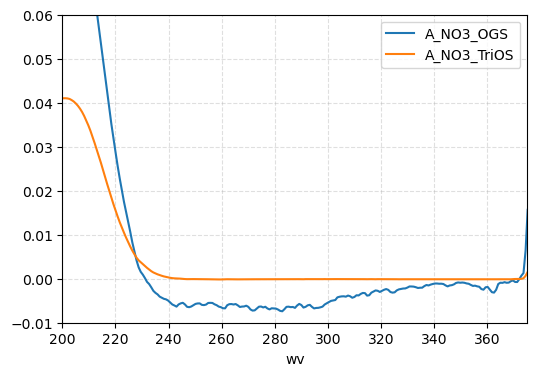

In [21]:
fig, ax = plt.subplots(1, figsize=[6,4])
ax.plot(ds2['wv'], -np.log10(np.mean(I_corr, axis=0) / ds_Ipw['IpwR0T0'].values), label='A_NO3_OGS')

A_NO3_trios.plot(ax=ax)

ax.legend()
ax.grid(ls='--', alpha=0.4)

ax.set_xlim([200, 375])
ax.set_ylim([-0.01, 0.06])

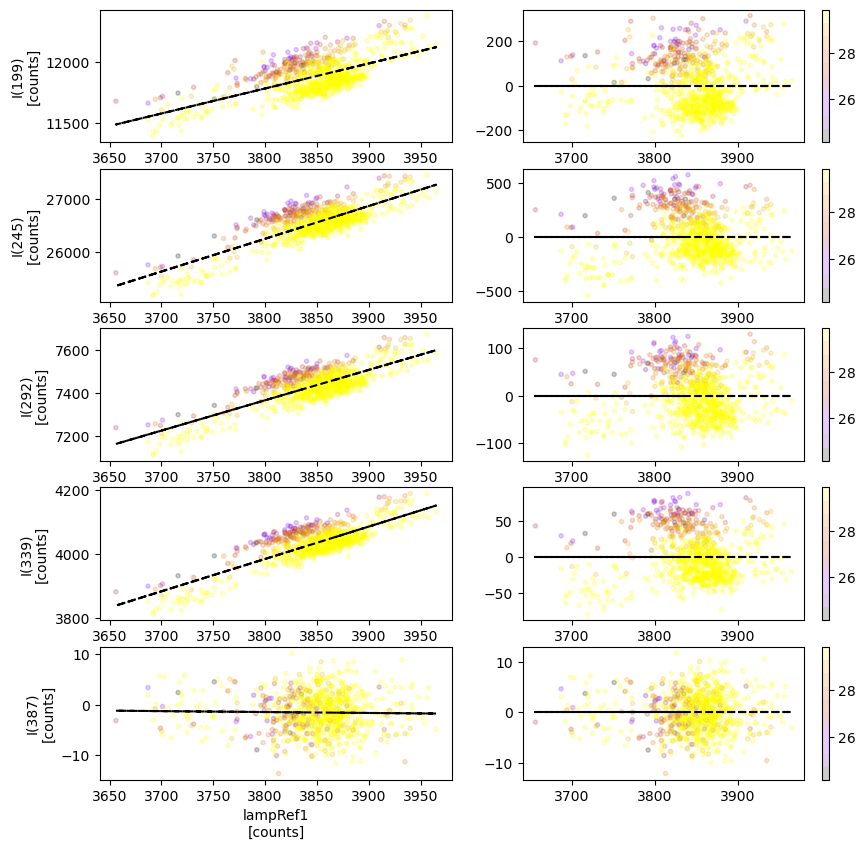

In [16]:
m = np.empty(wv.size) * np.nan
q = np.empty(wv.size) * np.nan

n_plots = 5
fig, ax = plt.subplots(n_plots, 2, figsize=[10,2*n_plots])



for ii,ip in enumerate(np.linspace(11, wv.size, n_plots).astype(int)-1):
    h = ax[ii,0].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T, c=ds2['T'], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,0].set_ylabel(f'I({wv[ip]:.0f})\n[counts]')
    ax[ii,0].set_xlabel(f'lampRef1\n[counts]')

    m[ii], q[ii] = np.polyfit(ds2['lampR1'], ds2['Intensity'][:,ip], 1)
    
    pred = m[ii] * ds2['lampR1'] + q[ii]
    ax[ii,0].plot(ds2['lampR1'], pred, 'k--')
    
    h = ax[ii,1].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T - pred, c=ds2['T'],  #TrefDiode_i[iLT24], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,1].plot(ds2['lampR1'], ds2['lampR1'][:]*0, 'k--')
    
    fig.colorbar(h)

In [22]:
T_col = 'T'
[m_lRef1, m_T] = op.cmp_R_T_corr(ds2, T_col, DIN)
m_lRef1_rob, m_T_rob, q = op.cmp_R_T_corr_robust(ds2, T_col, DIN)

Text(0, 0.5, 'm_T')

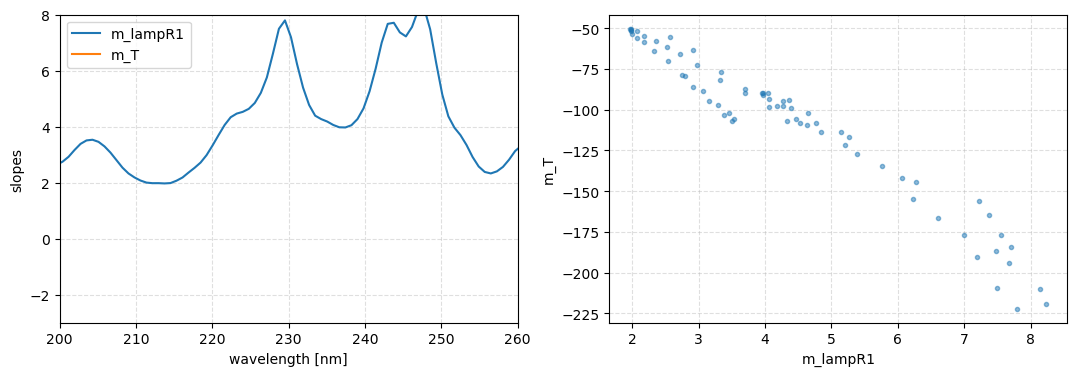

In [23]:
i200_255 = np.where( (ds2['wv'] >= 200) & (ds2['wv'] <= 255) )

fig, ax = plt.subplots(1,2, figsize=[13, 4])
ax[0].plot(ds2['wv'][:], m_lRef1[:], label='m_lampR1')
ax[0].plot(ds2['wv'][:], m_T[:]/10, label='m_T')
ax[0].legend()
ax[0].grid(ls='--', alpha=0.4)
ax[0].set_xlabel('wavelength [nm]')
ax[0].set_ylabel('slopes')
ax[0].set_ylim([-3, 8])
ax[0].set_xlim([200, 260])

ax[1].plot(m_lRef1[i200_255], m_T[i200_255], '.', alpha=0.5)
ax[1].grid(ls='--', alpha=0.4)
ax[1].set_xlabel('m_lampR1')
ax[1].set_ylabel('m_T')


In [32]:
# apply correction

io = 400

Io_Ro = ds2['Intensity'][io,:]
Io_R = np.empty(ds2['Intensity'].shape) 

dR = ds2['lampR1'].values - ds2['lampR1'][io].values
dT = ds2['T'].values - ds2['T'][io].values

Io_R_ = ds2['Intensity'][io,:].values.reshape(-1,1).T
Io_R  = ds2['Intensity'][io,:].values.reshape(-1,1).T +   m_lRef1 * dR.reshape(-1,1)   +   m_T * dT.reshape(-1,1)
Io_R_rob  = ds2['Intensity'][io,:].values.reshape(-1,1).T +   m_lRef1_rob * dR.reshape(-1,1)   +   m_T_rob * dT.reshape(-1,1)


T_  = ds2['Intensity'].values / Io_R_
A_not_corr  = -np.log10(np.asarray(T_))

T   = ds2['Intensity'].values / Io_R
A_corr = -np.log10(np.asarray(T))

T   = ds2['Intensity'].values / Io_R_rob
A_corr_rob = -np.log10(np.asarray(T))


WV  = np.ones([ds2['T'].size,1]) * wv.reshape(1,-1)

/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_77493/1367550316.py:17: RuntimeWarning: divide by zero encountered in log10
  A_not_corr  = -np.log10(np.asarray(T_))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_77493/1367550316.py:17: RuntimeWarning: invalid value encountered in log10
  A_not_corr  = -np.log10(np.asarray(T_))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_77493/1367550316.py:20: RuntimeWarning: divide by zero encountered in log10
  A_corr = -np.log10(np.asarray(T))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_77493/1367550316.py:20: RuntimeWarning: invalid value encountered in log10
  A_corr = -np.log10(np.asarray(T))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_77493/1367550316.py:23: RuntimeWarning: divide by zero encountered in log10
  A_corr_rob = -np.log10(np.asarray(T))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_77493/1367550316.py:23: RuntimeWarning: invalid value encountered in log

Text(164.22222222222223, 0.5, 'absorbance [-]')

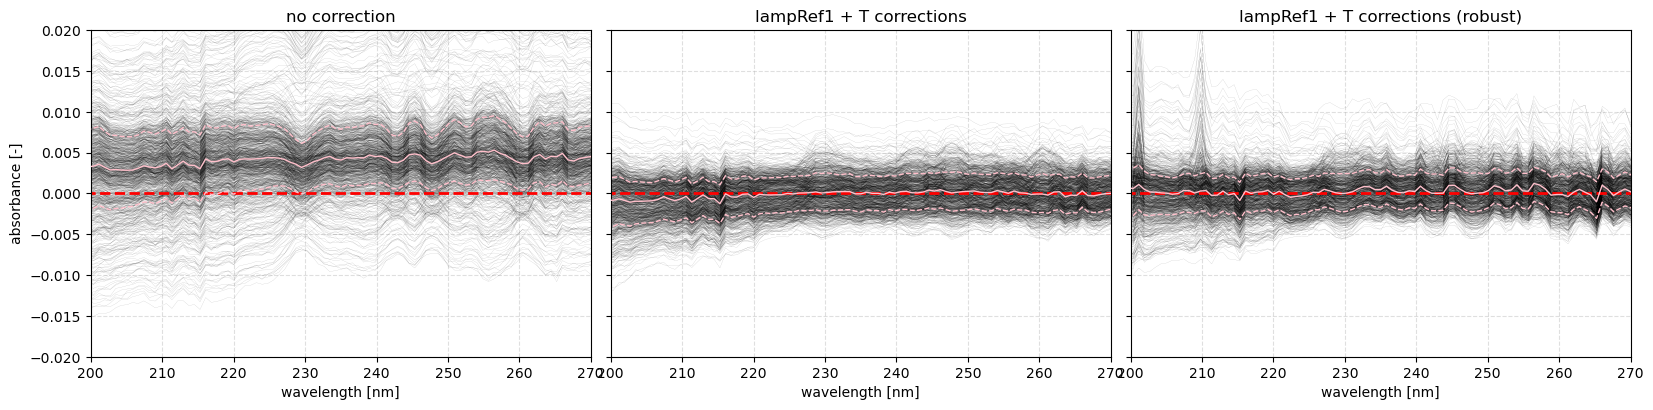

In [35]:
def make_line_collection(x, y_array, **kwargs):
    """
    Creates a LineCollection from a set of y-series sharing the same x-axis.
    x: 1D array of shape (M,)
    y_array: 2D array of shape (N, M)
    """
    # Each line segment is an array of shape (M, 2)
    segments = [np.column_stack((x, y)) for y in y_array]
    return LineCollection(segments, **kwargs)

fig, ax = plt.subplots(1, 3, figsize=[16, 4], sharex=True, sharey=True)

datasets = [
    (A_not_corr, 0),
    (A_corr, 1),
    (A_corr_rob, 2)
]

for data, i in datasets:
    # Ensure data is shaped (N, M) where M == len(wv)
    if data.shape[1] != len(wv):
        data = data.T  # transpose if needed

    lc = make_line_collection(wv, data, colors='k', linewidths=0.1, alpha=0.4)
    ax[i].add_collection(lc)
    
    ax[i].plot(wv, np.zeros_like(wv), lw=2, ls='--', c='r', alpha=1)

    median = np.nanmedian(data, axis=0)
    p16 = np.nanpercentile(data, 16, axis=0)
    p84 = np.nanpercentile(data, 84, axis=0)

    ax[i].plot(wv, median, lw=1, c='pink', zorder=60)
    ax[i].plot(wv, p84, '--', lw=1, c='pink', zorder=60)
    ax[i].plot(wv, p16, '--', lw=1, c='pink', zorder=60)

    ax[i].autoscale()  # Important when using LineCollection

    ax[i].set_xlabel('wavelength [nm]')
    ax[i].grid(ls='--', alpha=0.4)
    
plt.tight_layout()


ax[0].set_xlim([200, 270])
ax[0].set_ylim([-0.02, 0.02])
# ax[2].set_ylim([-0.025, 0.01])


ax[0].set_title('no correction')
ax[1].set_title('lampRef1 + T corrections')
ax[2].set_title('lampRef1 + T corrections (robust)')

ax[0].set_ylabel('absorbance [-]')
# ax[0].set_ylabel('absorbance [-]')

In [37]:
i200_255 = np.where((ds2['wv'] >= 200) & (ds2['wv'] <= 255))[0]

A_flat = A_not_corr[:,i200_255].flatten()
innan_ = np.where(~np.isnan(A_flat))[0]
print((np.nanpercentile(A_flat[innan_], 84) - np.nanpercentile(A_flat[innan_], 16)) / 2 / np.nanpercentile(A_flat[innan_], 50))
# print( np.nanstd(A_flat[innan_]) / np.nanmean(A_flat[innan_]))
print()

Aflat = A_corr[:,i200_255].flatten()
innan = np.where(~np.isnan(Aflat))[0]
print((np.nanpercentile(Aflat[innan], 84) - np.nanpercentile(Aflat[innan], 16)) / 2 / np.nanpercentile(Aflat[innan], 50))
# print( np.nanstd(Aflat[innan_]) / np.nanmean(Aflat[innan_]))
print()

A__flat = A_corr_rob[:,i200_255].flatten()
innan = np.where(~np.isnan(A__flat))[0]
print((np.nanpercentile(A__flat[innan], 84) - np.nanpercentile(A__flat[innan], 16)) / 2 / np.nanpercentile(A__flat[innan], 50))
# print( np.nanstd(A__flat[innan_]) / np.nanmean(A__flat[innan_]))

0.9674960341228469

-14.906479236873624

9.936990811191693


In [145]:
ds2['T'].shape

(1446,)